In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interacted_before_leaving.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interacted_before_leaving.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interacted_before_leaving.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interacted_before_leaving.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interacted_before_leaving.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interacted_before_leaving.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


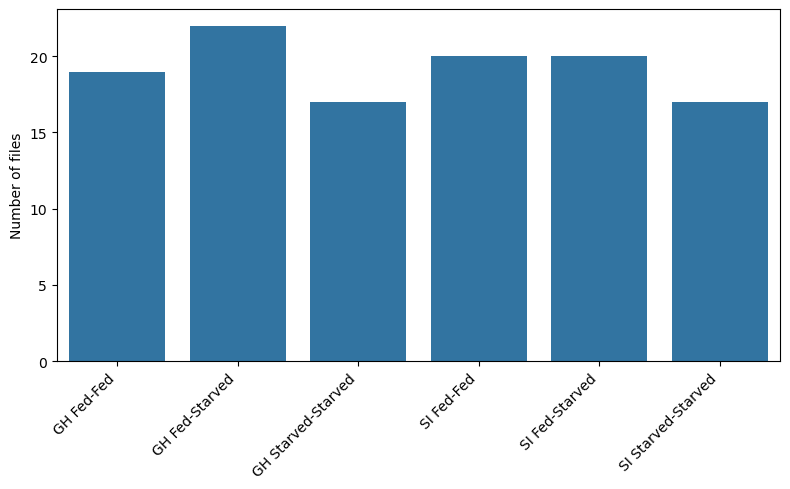

In [2]:
counts = (
    df.groupby('Condition')
    .size()
    .reset_index(name='n_files')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=counts,
    x='Condition',
    y='n_files'
)

plt.ylabel('Number of files')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

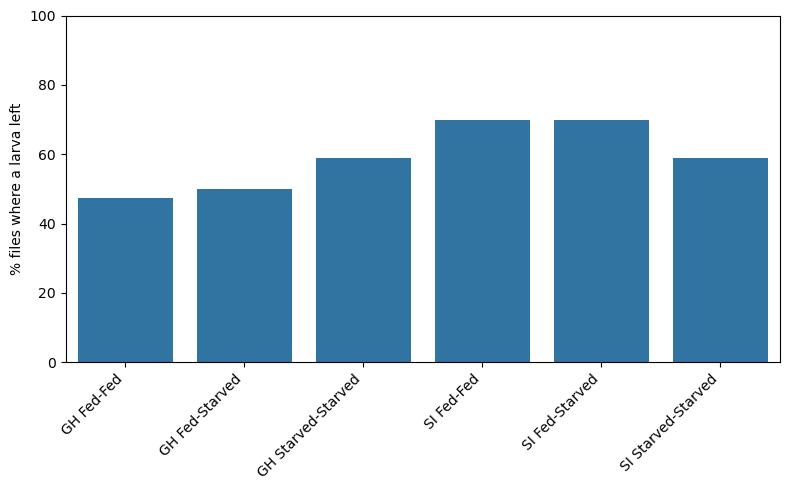

In [3]:
leave_summary = (
    df.groupby('Condition')['left']
    .mean()
    .mul(100)
    .reset_index(name='percent_left')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=leave_summary,
    x='Condition',
    y='percent_left'
)

plt.ylabel('% files where a larva left')
plt.xlabel('')
plt.ylim(0, 100)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

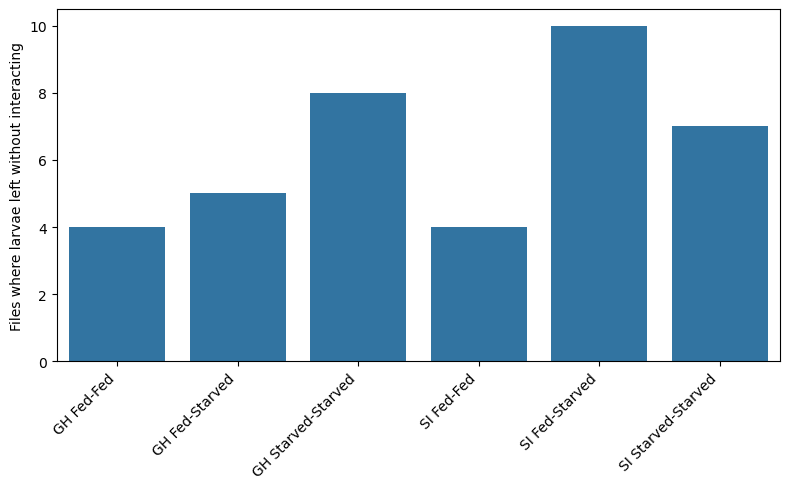

In [5]:
never_interacted = (
    df[
        (df["left"]) &
        (~df["interacted_before_leaving"])
    ]
    .groupby("Condition")
    .size()
    .reset_index(name="n_files")
)


plt.figure(figsize=(8,5))

sns.barplot(
    data=never_interacted,
    x="Condition",
    y="n_files"
)

plt.ylabel("Files where larvae left without interacting")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

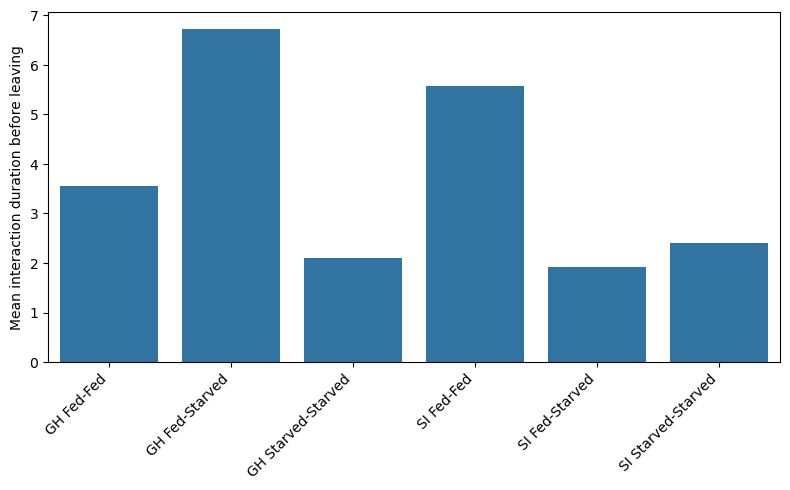

In [4]:
left_df = df[df["left"]].copy()

duration_summary = (
    left_df.groupby("Condition")["total_interaction_duration_before_leaving"]
    .mean()
    .reset_index(name="mean_contact_duration")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=duration_summary,
    x="Condition",
    y="mean_contact_duration"
)

plt.ylabel("Mean interaction duration before leaving")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

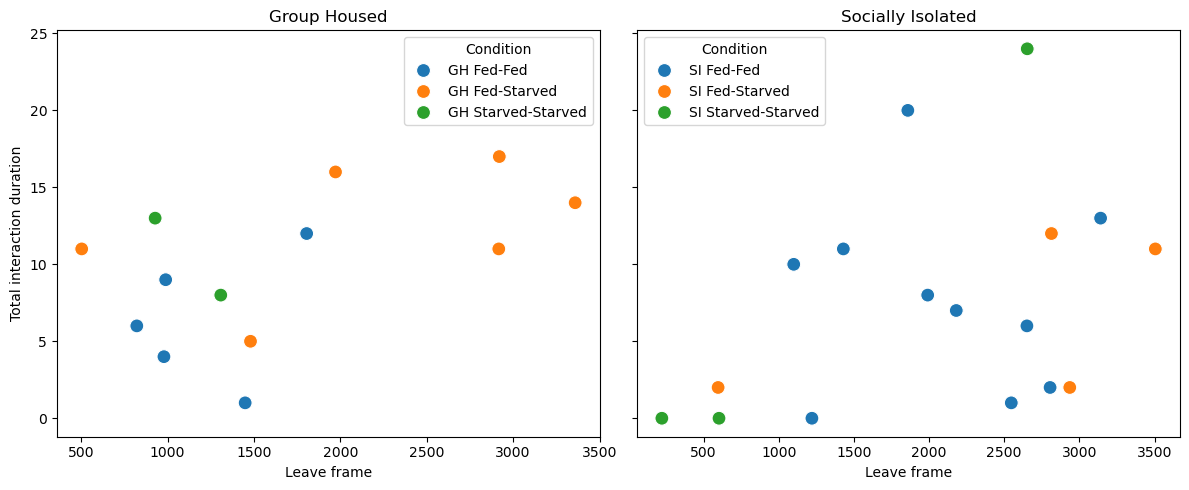

In [7]:
scatter_df = df[
    (df["left"]) &
    (df["interacted_before_leaving"])
].copy()

si_df = scatter_df[scatter_df["Condition"].str.contains("SI")]
gh_df = scatter_df[scatter_df["Condition"].str.contains("GH")]



fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(
    data=gh_df,
    x="leave_frame",
    y="total_interaction_duration_before_leaving",
    hue="Condition",
    s=100,
    ax=axes[0]
)

axes[0].set_title("Group Housed")
axes[0].set_xlabel("Leave frame")
axes[0].set_ylabel("Total interaction duration")

sns.scatterplot(
    data=si_df,
    x="leave_frame",
    y="total_interaction_duration_before_leaving",
    hue="Condition",
    s=100,
    ax=axes[1]
)

axes[1].set_title("Socially Isolated")
axes[1].set_xlabel("Leave frame")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

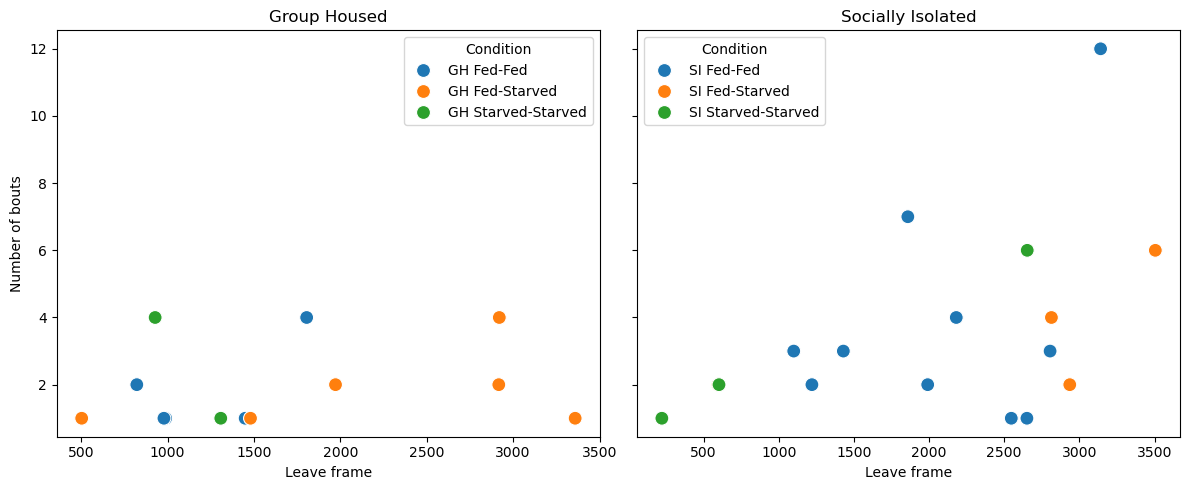

In [8]:
scatter_df = df[
    (df["left"]) &
    (df["interacted_before_leaving"])
].copy()

si_df = scatter_df[scatter_df["Condition"].str.contains("SI")]
gh_df = scatter_df[scatter_df["Condition"].str.contains("GH")]



fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(
    data=gh_df,
    x="leave_frame",
    y="n_bouts_before_leaving",
    hue="Condition",
    s=100,
    ax=axes[0]
)

axes[0].set_title("Group Housed")
axes[0].set_xlabel("Leave frame")
axes[0].set_ylabel("Number of bouts")

sns.scatterplot(
    data=si_df,
    x="leave_frame",
    y="n_bouts_before_leaving",
    hue="Condition",
    s=100,
    ax=axes[1]
)

axes[1].set_title("Socially Isolated")
axes[1].set_xlabel("Leave frame")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()